In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df_image = pd.read_csv("image_models_results.csv")
df_raw = pd.read_csv("raw_models_results.csv")
df_all = pd.concat([df_image, df_raw], ignore_index=True)

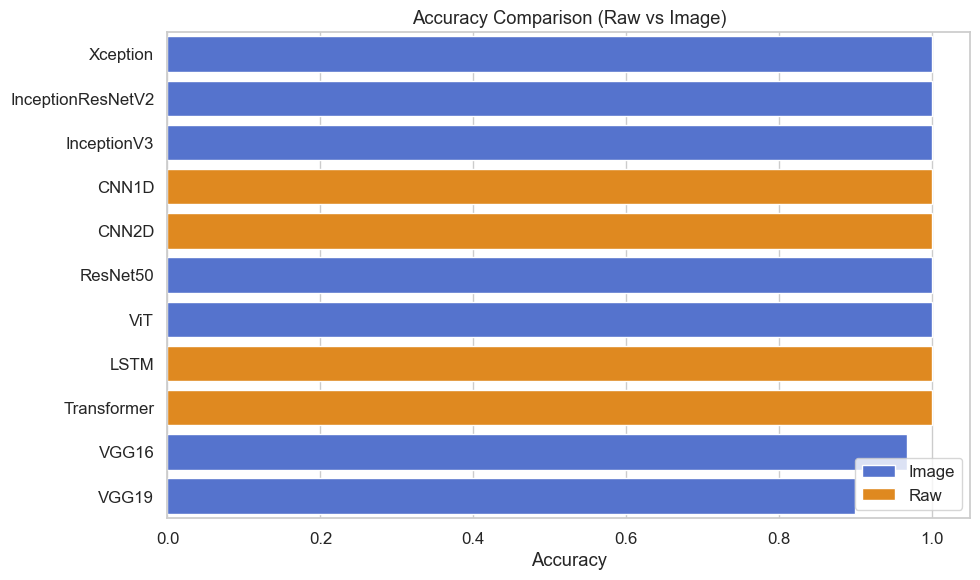

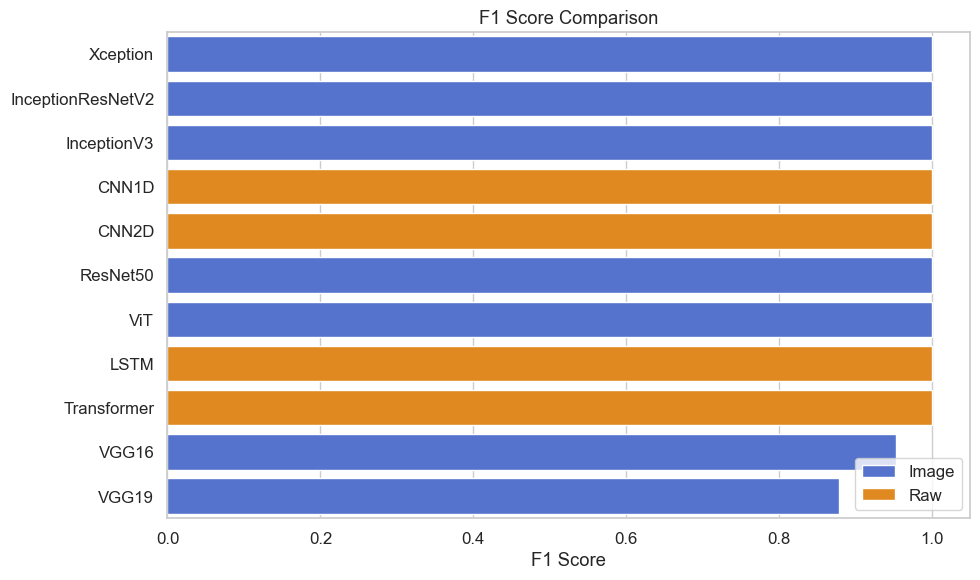

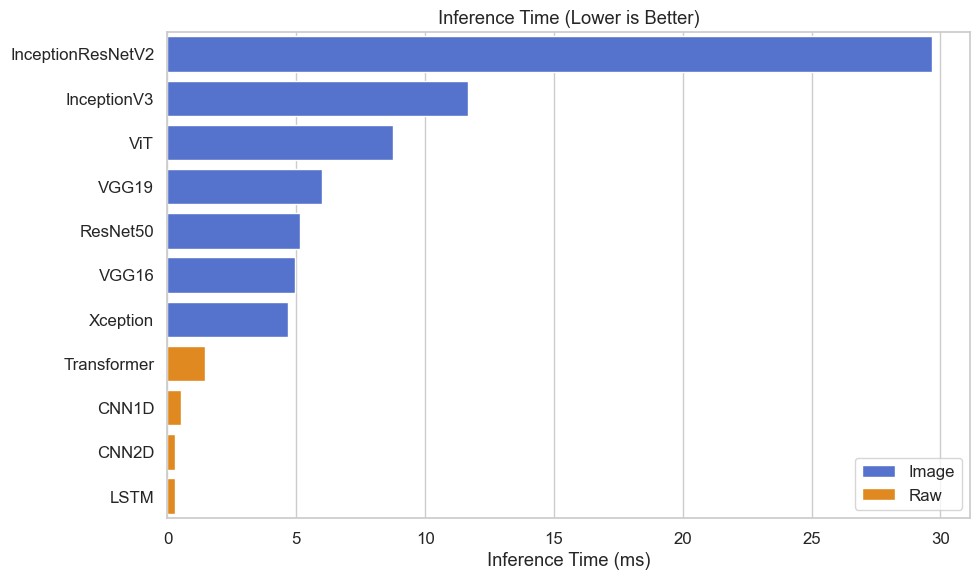

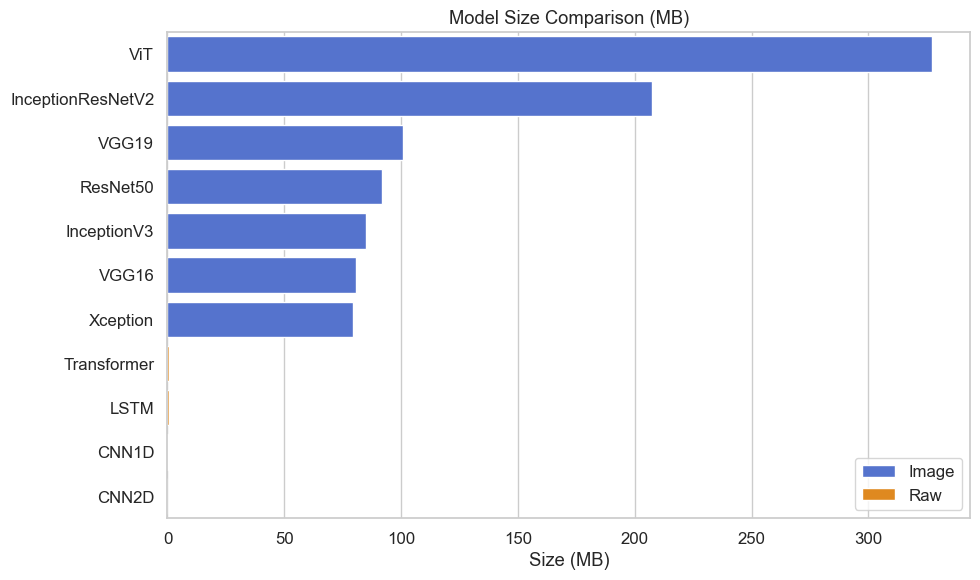

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df_image = pd.read_csv("image_models_results.csv")
df_raw = pd.read_csv("raw_models_results.csv")
df_all = pd.concat([df_image, df_raw], ignore_index=True)

# Set Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


# Chart function using seaborn
def plot_grouped_bar_seaborn(df, metric, title, ylabel=None):
    plt.figure(figsize=(10, 6))
    sorted_df = df.sort_values(metric, ascending=False)
    ax = sns.barplot(
        data=sorted_df,
        y="Model",
        x=metric,
        hue="Type",
        dodge=False,
        palette={"Image": "royalblue", "Raw": "darkorange"},
    )
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel(ylabel if ylabel else "")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# Plot comparisons
plot_grouped_bar_seaborn(df_all, "Accuracy", "Accuracy Comparison (Raw vs Image)")
plot_grouped_bar_seaborn(df_all, "F1 Score", "F1 Score Comparison")
plot_grouped_bar_seaborn(
    df_all, "Inference Time (ms)", "Inference Time (Lower is Better)"
)
plot_grouped_bar_seaborn(df_all, "Size (MB)", "Model Size Comparison (MB)")

# Save combined CSV
df_all.to_csv("all_model_comparison.csv", index=False)

In [3]:
from math import pi
import numpy as np


def plot_radar_chart(df, models, metrics, title="Radar Chart Comparison"):
    # Normalize all selected metrics to 0–1
    df_norm = df.copy()
    for metric in metrics:
        max_val = df[metric].max()
        min_val = df[metric].min()
        df_norm[metric] = (df[metric] - min_val) / (max_val - min_val + 1e-8)

    # Prepare data in radar-friendly format
    radar_df = df_norm[df_norm["Model"].isin(models)].set_index("Model")[metrics]

    # Add first column to the end to complete the loop
    radar_df = radar_df.T
    radar_df["metric"] = radar_df.index
    radar_df = radar_df.set_index("metric")
    radar_df = pd.concat([radar_df, radar_df.iloc[[0]]])

    # Plot
    plt.figure(figsize=(8, 8))
    categories = radar_df.index.tolist()
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]

    ax = plt.subplot(111, polar=True)

    for model in radar_df.columns:
        values = radar_df[model].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(title, size=14, y=1.1)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

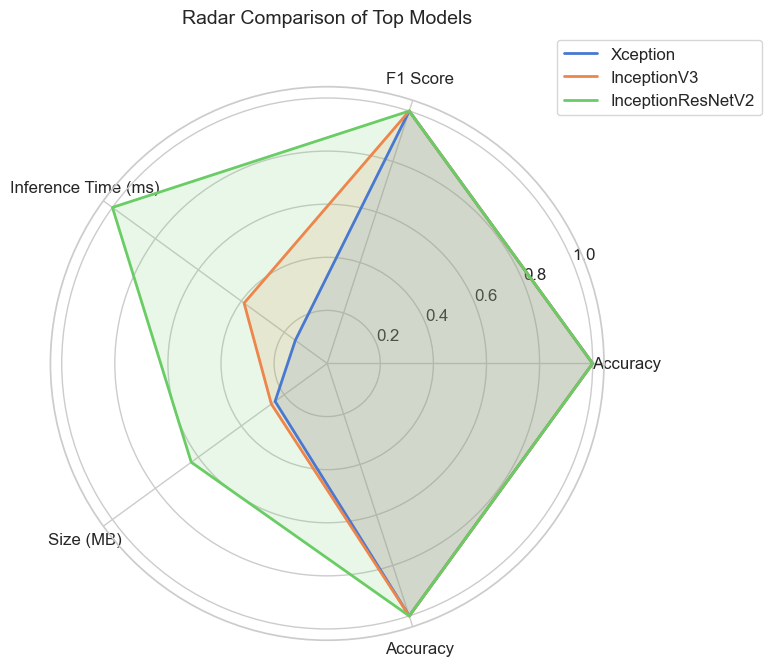

In [4]:
# Choose models to compare (top-3 by F1 for example)
top_models = df_all.sort_values("F1 Score", ascending=False).head(3)["Model"].tolist()

# Define the metrics you want to compare
radar_metrics = ["Accuracy", "F1 Score", "Inference Time (ms)", "Size (MB)"]

# Plot
plot_radar_chart(
    df_all, top_models, radar_metrics, title="Radar Comparison of Top Models"
)